# SOCP vs. QCQP: slicing a cone

**TL;DR.** Every convex QCQP is an SOCP, but not every SOCP is a convex QCQP: $\text{convex QCQP} \subsetneq \text{SOCP}$.

One picture explains the gap. A second-order cone constraint is a **slice of the cone $\{(x,t) : \|x\|_2 \le t\}$ by a hyperplane**, and the tilt of the hyperplane relative to the $45^\circ$ cone wall decides what the slice is:

| tilt of the plane | slice | convex quadratic constraint? |
| :-- | :-- | :-- |
| flatter than the wall | ellipsoid | yes |
| parallel to the wall | paraboloid | yes (singular $P$) |
| steeper than the wall | one sheet of a hyperboloid | **no**: SOCP only |

A convex quadratic inequality can describe ellipsoids and paraboloids but never a *single* sheet of a hyperboloid: squaring the norm brings the second sheet back, and the two sheets together are not convex. The norm constraint avoids this because $\|\cdot\|_2 \ge 0$ silently enforces $c^Tx + d \ge 0$, which throws the second sheet away.

## 1. The two problem classes

**Convex QCQP**: quadratic objective and constraints with positive semidefinite matrices.
$$\begin{array}{ll}
\text{minimize} & \tfrac12 x^T P_0 x + q_0^T x + r_0 \\
\text{subject to} & \tfrac12 x^T P_i x + q_i^T x + r_i \le 0, \quad i = 1,\dots,m, \\
& Fx = g,
\end{array}
\qquad P_0, P_i \in \mathbb{S}^n_+ .$$

**SOCP**: linear objective, and constraints that put an affine image of $x$ inside a second-order cone.
$$\begin{array}{ll}
\text{minimize} & f^T x \\
\text{subject to} & \|A_i x + b_i\|_2 \le c_i^T x + d_i, \quad i = 1,\dots,m, \\
& Fx = g,
\end{array}
\qquad A_i \in \mathbb{R}^{n_i \times n},\; b_i \in \mathbb{R}^{n_i},\; c_i \in \mathbb{R}^n,\; d_i \in \mathbb{R}.$$

Two things to keep in mind: an SOC constraint implies $c_i^Tx + d_i \ge 0$ (a norm is never negative), and for $c_i = 0$ it is just a norm bound $\|A_i x + b_i\|_2 \le d_i$.

## 2. Convex QCQP $\to$ SOCP

Two standard tricks.

**Epigraph for the objective.** Introduce $t \in \mathbb{R}$ and minimize $t$ subject to $\tfrac12 x^TP_0x + q_0^Tx + r_0 \le t$. The objective is now linear, and the new constraint is a convex quadratic inequality in $(x, t)$.

**Difference of squares for each constraint.** Since $P \succeq 0$ we can factor $P = A^TA$ (e.g. $A = P^{1/2}$). With the affine quantity $u := -2(q^Tx + r)$ the constraint reads $\|Ax\|_2^2 \le u$, and
$$\|Ax\|_2^2 \le u \iff \left\|\begin{pmatrix} 2Ax \\ u - 1\end{pmatrix}\right\|_2 \le u + 1,$$
because $(u+1)^2 - (u-1)^2 = 4u$. ($\Leftarrow$: square both sides. $\Rightarrow$: $\|Ax\|_2^2 \le u$ forces $u \ge 0$, so $u + 1 > 0$ and taking square roots is legitimate.) The right-hand side is a second-order cone constraint in $x$.

So every convex quadratic inequality is an SOC constraint. The converse fails, and the picture below shows exactly where.

## 3. The picture: slicing the cone

Take a single SOC constraint with $A = I$, $b = 0$:
$$\|x\|_2 \le c^Tx + d, \qquad x \in \mathbb{R}^n,\; d > 0.$$
(For invertible $A$ substitute $u = Ax + b$; this only replaces $c$ by $A^{-T}c$, the picture is unchanged. $d > 0$ means the plane passes above the apex; otherwise the set is empty or a single point.)

Lift to $\mathbb{R}^{n+1}$ with an extra vertical coordinate $t$:

- the **second-order cone** $\mathcal{K} = \{(x,t) : \|x\|_2 \le t\}$ is a solid cone whose wall makes a $45^\circ$ angle with the $x$-space;
- the **hyperplane** $t = c^Tx + d$ has slope $\|c\|_2$ and passes at height $d$ above the apex.

A point $x$ is feasible iff the point of the plane above it, $(x, c^Tx + d)$, lies inside $\mathcal{K}$. So **the feasible set is the shadow of $\text{plane} \cap \mathcal{K}$ on $x$-space**, and because the plane is a graph over $x$-space the shadow has the same shape as the slice. Slicing a cone with a plane gives a conic section, and which one depends only on the slope $\|c\|_2$ compared with the $45^\circ$ wall:

| slope $\lVert c\rVert_2$ | plane vs. wall | slice = feasible set | $P = I - cc^T$ |
| :-: | :-- | :-- | :-- |
| $< 1$ | flatter | closed ellipse: a bounded **ellipsoid** ($c = 0$: a ball) | $\succ 0$ |
| $= 1$ | parallel to one generator | **paraboloid**, unbounded in the direction $c$ | $\succeq 0$, one zero eigenvalue |
| $> 1$ | steeper | **one sheet of a hyperboloid**; the same plane also cuts the lower nappe $t = -\lVert x\rVert_2$, producing a second sheet that the SOC constraint does *not* contain | indefinite: eigenvalue $1 - \lVert c\rVert_2^2 < 0$ along $c$ |

The last column is the matrix obtained by squaring the constraint, $x^T(I - cc^T)x - 2d\,c^Tx - d^2 \le 0$, i.e. the $P$ a QCQP would have to use. Its eigenvalues are $1$ ($n-1$ times) and $1 - \|c\|_2^2$, so *"steeper than the wall" and "$P$ is indefinite" are the same statement.*

**Figure 1.** Cone (red; the lower nappe is faded because the SOC constraint never sees it), plane (teal), and their intersection (black). Dashed grey: the intersection with the lower nappe, which exists only for $\|c\|_2 > 1$. The panels are interactive, rotate them.

In [4]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

d, R = 1.0, 4.0  # plane height above the apex, half-width of the plotted box
cases = [(0.5, "‖c‖ = 0.5 < 1: ellipse"),
         (1.0, "‖c‖ = 1: parabola"),
         (2.0, "‖c‖ = 2 > 1: hyperbola (2nd branch on the lower nappe)")]
CONE, PLANE, INK, GHOST = "#D9534F", "#3FA7A3", "#222222", "#8A8A8A"

# cone t = ±‖x‖ in polar coordinates, plane t = c·x + d on a grid
r, th = np.meshgrid(np.linspace(0, R, 40), np.linspace(0, 2 * np.pi, 91))
Xc, Yc = r * np.cos(th), r * np.sin(th)
Xp, Yp = np.meshgrid(np.linspace(-R, R, 81), np.linspace(-R, R, 81))


def surface(x, y, z, color, opacity):
    return go.Surface(x=x, y=y, z=z, colorscale=[[0, color], [1, color]], showscale=False,
                      opacity=opacity, hoverinfo="skip",
                      lighting=dict(ambient=0.7, diffuse=0.5, specular=0.05, roughness=0.9))


def slice_curve(c, sign):
    """Plane ∩ nappe t = sign·‖x‖, solved in polar coordinates: r·(sign − c·cosθ) = d."""
    t = np.linspace(0, 2 * np.pi, 600)
    den = sign - c * np.cos(t)
    with np.errstate(divide="ignore"):
        rr = np.where(den > 1e-9, d / den, np.nan)
    rr = np.where(rr <= 1.5 * R, rr, np.nan)  # keep only the part near the box
    return rr * np.cos(t), rr * np.sin(t), sign * rr


fig = make_subplots(rows=1, cols=3, specs=[[{"type": "surface"}] * 3],
                    subplot_titles=[title for _, title in cases], horizontal_spacing=0.01)

for col, (c, _) in enumerate(cases, start=1):
    Zp = c * Xp + d
    Zp = np.where(np.abs(Zp) <= R, Zp, np.nan)  # clip the plane to the box
    fig.add_trace(surface(Xc, Yc, r, CONE, 0.55), row=1, col=col)   # upper nappe (the cone K)
    fig.add_trace(surface(Xc, Yc, -r, CONE, 0.18), row=1, col=col)  # lower nappe (only after squaring)
    fig.add_trace(surface(Xp, Yp, Zp, PLANE, 0.45), row=1, col=col)
    x, y, z = slice_curve(c, +1)
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode="lines", line=dict(color=INK, width=8),
                               hoverinfo="skip"), row=1, col=col)
    x, y, z = slice_curve(c, -1)
    if np.isfinite(x).any():
        fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode="lines", line=dict(color=GHOST, width=8, dash="dash"),
                                   hoverinfo="skip"), row=1, col=col)

axis = dict(range=[-R, R], showbackground=False, gridcolor="#DDDDDD", zeroline=False, tickvals=[])
fig.update_scenes(aspectmode="cube", camera=dict(eye=dict(x=1.1, y=-2.0, z=0.55)),
                  xaxis={**axis, "title": "x₁"}, yaxis={**axis, "title": "x₂"}, zaxis={**axis, "title": "t"})
fig.update_layout(height=460, width=1280, showlegend=False, margin=dict(l=0, r=0, t=50, b=0),
                  paper_bgcolor="white")
fig.show()

**Figure 2.** The same three constraints in $x$-space, i.e. the shadow of the slice. Hatched: the second piece $\|x\|_2 \le -(c^Tx + d)$ that appears once the constraint is squared; together with the teal region it is visibly not convex.

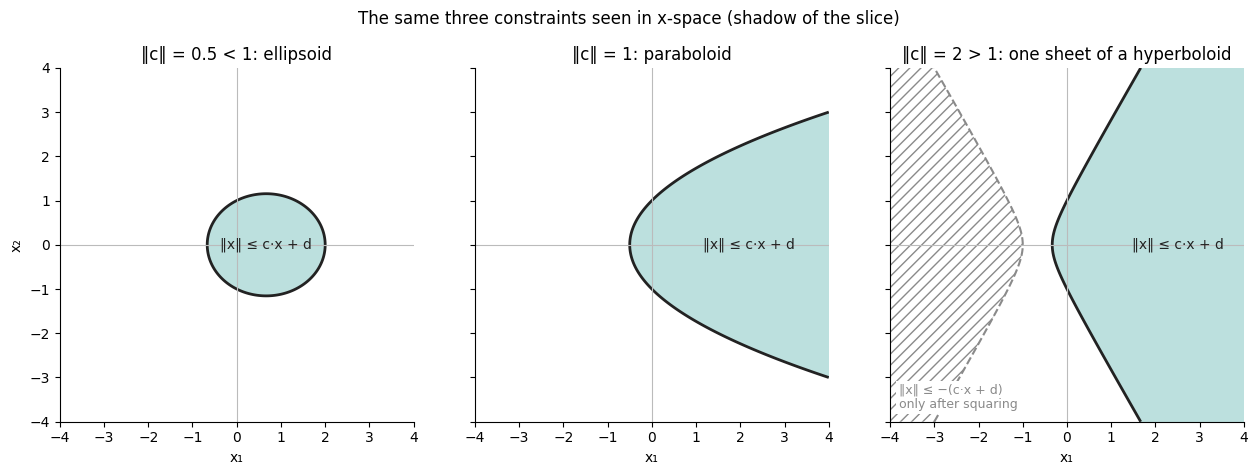

In [5]:
import numpy as np
import matplotlib.pyplot as plt

d = 1.0
cases = [(0.5, "‖c‖ = 0.5 < 1: ellipsoid"),
         (1.0, "‖c‖ = 1: paraboloid"),
         (2.0, "‖c‖ = 2 > 1: one sheet of a hyperboloid")]
PLANE, INK, GHOST = "#3FA7A3", "#222222", "#8A8A8A"

L = 4
x1, x2 = np.meshgrid(np.linspace(-L, L, 700), np.linspace(-L, L, 700))
nrm = np.hypot(x1, x2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True)
for ax, (c, title) in zip(axes, cases):
    feas = c * x1 + d - nrm          # ≥ 0  ⇔  ‖x‖ ≤ c·x + d      (the SOC constraint)
    ghost = -(c * x1 + d) - nrm      # ≥ 0  ⇔  ‖x‖ ≤ −(c·x + d)   (the extra piece squaring adds)
    ax.contourf(x1, x2, feas, levels=[0, feas.max() + 1], colors=[PLANE], alpha=0.35)
    ax.contour(x1, x2, feas, levels=[0], colors=[INK], linewidths=2)
    if (ghost > 0).any():
        plt.rcParams["hatch.color"] = GHOST
        ax.contourf(x1, x2, ghost, levels=[0, ghost.max() + 1], colors="none", hatches=["///"])
        ax.contour(x1, x2, ghost, levels=[0], colors=[GHOST], linewidths=1.5, linestyles="--")
        ax.text(-3.8, -3.7, "‖x‖ ≤ −(c·x + d)\nonly after squaring", color=GHOST, fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", pad=2))
    ax.text({0.5: 0.67, 1.0: 2.2, 2.0: 2.5}[c], 0, "‖x‖ ≤ c·x + d", color=INK, fontsize=10,
            ha="center", va="center")
    ax.axhline(0, color="#BBBBBB", lw=0.8)
    ax.axvline(0, color="#BBBBBB", lw=0.8)
    ax.set(xlim=(-L, L), ylim=(-L, L), aspect="equal", title=title, xlabel="x₁")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("x₂")
fig.suptitle("The same three constraints seen in x-space (shadow of the slice)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Why the steep slice is not a convex quadratic constraint

Squaring the constraint loses the sign information hidden in the norm:
$$\|x\|_2^2 \le (c^Tx + d)^2 \iff \|x\|_2 \le |c^Tx + d| \iff \underbrace{\|x\|_2 \le c^Tx + d}_{\text{upper nappe}} \;\;\text{or}\;\; \underbrace{\|x\|_2 \le -(c^Tx + d)}_{\text{lower nappe}}.$$

- If $\|c\|_2 \le 1$ the second set is **empty**: by Cauchy–Schwarz, $-(c^Tx + d) \le \|c\|_2\|x\|_2 - d < \|x\|_2$. Squaring is lossless, and the squared constraint is a convex quadratic inequality with $P = I - cc^T \succeq 0$. This is the ellipsoid / paraboloid case.
- If $\|c\|_2 > 1$ the second set is **non-empty** (take $x = -\lambda c$ with $\lambda$ large). The squared constraint now describes *both* sheets of a two-sheeted hyperboloid, a non-convex set, and accordingly $P = I - cc^T$ is indefinite. The original SOC constraint keeps only the upper sheet because it implies the linear inequality $c^Tx + d \ge 0$.

Could a QCQP keep the squared constraint and add $c^Tx + d \ge 0$ by hand? The resulting *set* is convex, but the *description* is not: the constraint function has an indefinite $P$, and convex QCQP is defined by $P_i \succeq 0$, not by convexity of the feasible set. More fundamentally, the zero level set of a convex quadratic is an ellipsoid, a paraboloid, a cylinder over one of these, or one or two parallel hyperplanes. A hyperboloid sheet is never among them, so one sheet of a hyperboloid can be the feasible set of an SOCP but never of a convex QCQP in the same variables.

## 5. Cheat sheet

For the constraint $\|x\|_2 \le c^Tx + d$ with $d > 0$ (for a general invertible $A$ read $A^{-T}c$ for $c$; a singular $A$ adds directions in which the set is a cylinder or a slab):

| slice of the cone | $\lVert c\rVert_2$ | $P = I - cc^T$ | feasible set in $\mathbb{R}^n$ | convex QCQP | SOCP |
| :-- | :-: | :-- | :-- | :-: | :-: |
| horizontal | $0$ | $I \succ 0$ | ball | ✓ | ✓ |
| flatter than the wall | $< 1$ | $\succ 0$ | tilted ellipsoid | ✓ | ✓ |
| parallel to the wall | $= 1$ | $\succeq 0$, singular | paraboloid | ✓ | ✓ |
| steeper than the wall | $> 1$ | indefinite | one sheet of a hyperboloid | ✗ | ✓ |
| both nappes (the squared constraint) | $> 1$ | indefinite | two sheets, non-convex | ✗ | ✗ |